# KI Vorlesung – Einstieg: Lineare Regression

Dieses Notebook zeigt ein einfaches Beispiel für Gradient Descent.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import helper_utils

## Datengenerierung

In [2]:
# Distances in miles for recent bike deliveries
distances = torch.tensor([[1.0], [2.0], [3.0], [4.0]], dtype=torch.float32)

# Corresponding delivery times in minutes
times = torch.tensor([[6.96], [12.11], [16.77], [22.21]], dtype=torch.float32)

## Die Daten Plotten

In [3]:
model = nn.Sequential(nn.Linear(1, 1))

## Werte des Modells berechnen

In [4]:
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [5]:
for epoch in range(500):
    # Reset the optimizer's gradients
    optimizer.zero_grad()
    # Make predictions (forward pass)
    outputs = model(distances)
    # Calculate the loss
    loss = loss_function(outputs, times)
    # Calculate adjustments (backward pass)
    loss.backward()
    # Update the model's parameters
    optimizer.step()
    # Print loss every 50 epochs
    if (epoch + 1) % 50 == 0:
       print(f"Epoch {epoch + 1}: Loss = {loss.item()}")

Epoch 50: Loss = 0.02774135023355484
Epoch 100: Loss = 0.027136752381920815
Epoch 150: Loss = 0.026691462844610214
Epoch 200: Loss = 0.026361342519521713
Epoch 250: Loss = 0.026116840541362762
Epoch 300: Loss = 0.025935662910342216
Epoch 350: Loss = 0.025801340118050575
Epoch 400: Loss = 0.025701873004436493
Epoch 450: Loss = 0.025628160685300827
Epoch 500: Loss = 0.025573553517460823


## Wert der Kostenfunktion berechnen

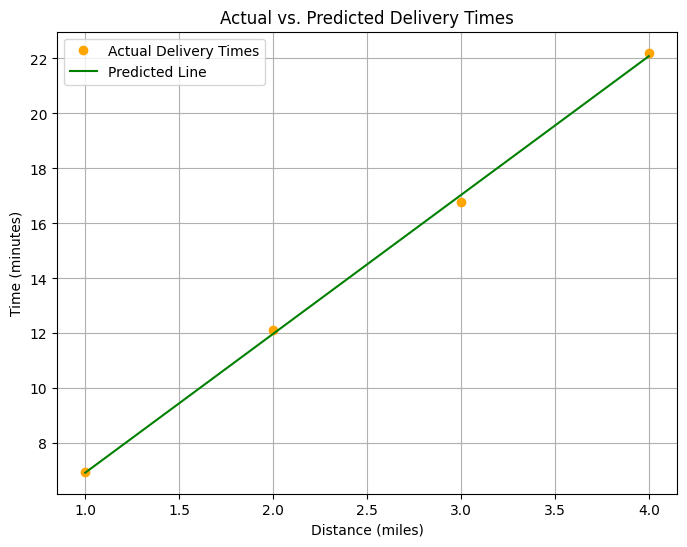

In [6]:
helper_utils.plot_results(model, distances, times)

## Gradient berechnen

In [ ]:
distance_to_predict = 7.0

# Use the torch.no_grad() context manager for efficient predictions
with torch.no_grad():
    # Convert the Python variable into a 2D PyTorch tensor that the model expects
    new_distance = torch.tensor([[distance_to_predict]], dtype=torch.float32)
    
    # Pass the new data to the trained model to get a prediction
    predicted_time = model(new_distance)
    
    # Use .item() to extract the scalar value from the tensor for printing
    print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time.item():.1f} minutes")

    # Use the scalar value in a conditional statement to make the final decision
    if predicted_time.item() > 30:
        print("\nDecision: Do NOT take the job. You will likely be late.")
    else:
        print("\nDecision: Take the job. You can make it!")

## Gradientenverfahren

In [ ]:
# Access the first (and only) layer in the sequential model
layer = model[0]

# Get weights and bias
weights = layer.weight.data.numpy()
bias = layer.bias.data.numpy()

print(f"Weight: {weights}")
print(f"Bias: {bias}")